In [2]:
# Machine Learning

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_data.csv")
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,TotalCharges,Churn,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,0,1,0,0,...,29.85,0,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,...,1889.50,0,True,False,False,True,False,False,False,True
2,0,0,0,2,1,0,1,1,0,0,...,108.15,1,True,False,False,False,False,False,False,True
3,0,0,0,45,0,0,1,0,1,1,...,1840.75,0,True,False,False,True,False,False,False,False
4,0,0,0,2,1,0,0,0,0,0,...,151.65,1,False,True,False,False,False,False,True,False


In [4]:
X = df.drop(columns=["Churn"])  # Isolate Churn
y = df["Churn"]
print(X.shape, y.shape)

(7043, 23) (7043,)


##### Training

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")

Train: 5634 rows
Test: 1409 rows


##### Logistic Regression

In [6]:
baseline = Pipeline(
    [
        # Scaling matters here: LogisticRegression is sensitive to feature magnitude
        # (tenure ~0-72 vs TotalCharges ~0-8000). Inside the pipeline it learns
        # only from train data, avoiding leakage.
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(max_iter=1000, class_weight="balanced"),
        ),  # class_weight handles the 26/74 imbalance so the model doesn't ignore churners
    ]
)

baseline.fit(X_train, y_train)

print("Baseline trained")

Baseline trained


##### Exam

In [7]:
# Prediction
y_pred = baseline.predict(X_test)

# Accuracy of the predictions
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.739

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### Baseline - Logistic Regression

Logistic Regression was selected as the baseline model. Being simple, fast and easy to
interpret, it provides a sensible reference point before moving on to more complex algorithms.
The model was wrapped in a pipeline together with a scaler, since Logistic Regression is
sensitive to feature scale, and `class_weight="balanced"` was used to compensate for the
class imbalance (roughly 26% churn).

**Results on the test set:**

| Metric (churn class) | Score |
|----------------------|-------|
| Recall               | 0.78  |
| Precision            | 0.51  |
| F1-score             | 0.61  |
| Accuracy (overall)   | 0.74  |

**Interpretation:**

The results on the test set are summarised below:

- **Recall (churn): 0.78**:  the most relevant metric in this context. The model correctly
  identifies around 78% of the customers who actually churned.
- **Precision (churn): 0.51**: when a customer is flagged as a churner, the prediction is
  correct about half of the time.
- **Accuracy: 0.74**: reasonable at first glance, but somewhat misleading here. Given that
  74% of customers do not churn, a model predicting "no churn" for everyone would already
  reach a similar figure, which is why accuracy is not a reliable measure on its own.

The high recall comes at the expense of lower precision, which is an expected consequence of
prioritising the churn class. For this particular problem the trade-off is acceptable: offering
a retention incentive to a customer who was not going to leave is inexpensive, whereas failing
to detect one who does leave is far more costly.

Overall, this is a solid first result and sets the benchmark to be improved upon with more
advanced models such as Random Forest and XGBoost.



##### ROG_AUC

In [8]:
# evaluates the model across all decision thresholds, not just the default 0.5
y_proba = baseline.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC", round(auc, 3))

ROC-AUC 0.841


##### Random Forest

In [9]:
# Captures non-linear patterns
rf = RandomForestClassifier(
    n_estimators=300,  # N number of trees, more stable but slower
    class_weight="balanced",
    random_state=42,
)

rf.fit(X_train, y_train)

# Evaluation with the same metrics used for the baseline
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))
print("\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.789
ROC-AUC: 0.828

               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



### Random Forest vs. Baseline

A Random Forest was trained next, expecting the additional model complexity to
improve performance. The results, however, tell a more nuanced story:

| Metric (churn class) | Logistic Regression | Random Forest |
|----------------------|:-------------------:|:-------------:|
| Recall               | 0.78                | 0.48          |
| Precision            | 0.51                | 0.64          |
| ROC-AUC              | 0.841               | 0.828         |
| Accuracy (overall)   | 0.74                | 0.79          |

At first glance the Random Forest looks stronger, since its overall accuracy is
higher (0.79 vs 0.74). That improvement is misleading. The model achieves it by
leaning towards the majority class, which inflates accuracy but causes recall on
the churn class to drop sharply, from 0.78 to 0.48. In practice this means almost
half of the customers who actually churn are now missed, precisely the cases the
business most needs to detect.

The ROC-AUC confirms this: at 0.828 it is slightly below the baseline's 0.841,
indicating that the untuned Random Forest separates the two classes no better than
the simpler model.

The takeaway is that a more complex model is not automatically a better one, and
that overall accuracy is a poor guide on imbalanced data. For this problem the
Logistic Regression baseline remains the stronger choice so far. The Random Forest
still has room to improve through hyperparameter tuning, which is explored later.


##### XGBoost

In [10]:
# Scale_pos_weight = (negative samples / positive samples)
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=scale,
    eval_metric="logloss",
    random_state=42,
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_xgb), 3))
print("\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.762
ROC-AUC: 0.831

               precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



### Model Comparison

Three models were trained and evaluated under the same conditions:

| Metric (churn) | Logistic Regression | Random Forest | XGBoost |
|----------------|:-------------------:|:-------------:|:-------:|
| Recall         | 0.78                | 0.48          | 0.76    |
| Precision      | 0.51                | 0.64          | 0.54    |
| F1-score       | 0.61                | 0.55          | 0.63    |
| ROC-AUC        | 0.841               | 0.828         | 0.831   |
| Accuracy       | 0.74                | 0.79          | 0.76    |

XGBoost offers the best overall balance (highest F1), while the Logistic Regression
baseline still leads on recall and ROC-AUC, the two metrics that matter most for
catching churners. Random Forest reaches the highest accuracy but the lowest recall,
which is the least useful profile for this problem.

The main takeaway is that a simple, well-built baseline remains competitive with more
complex models on this dataset. These results come from a single train/test split, so
they are validated with cross-validation before drawing final conclusions.


#### Cross Validation

In [11]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": baseline,
    "Random Forest": rf,
    "XGBoost": xgb,
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")
    print(f"{name:20s} ROC-AUC: {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression  ROC-AUC: 0.845 (+/- 0.014)
Random Forest        ROC-AUC: 0.826 (+/- 0.011)
XGBoost              ROC-AUC: 0.834 (+/- 0.011)



Each model was evaluated with 5-fold stratified cross-validation, scored on ROC-AUC,
to check that the results did not depend on a single split.

Logistic Regression scored highest (0.845), followed by XGBoost (0.834) and Random
Forest (0.826). All three had low standard deviations (around 0.01), so their
performance is stable across folds and the comparison is reliable.

The single-split ranking holds: a simple linear model beats both ensemble methods here.
Since XGBoost was run with default parameters, it is tuned next before the final model
is chosen with GridSearchCV


##### GridSearchCV in XGBoost

In [12]:
from sklearn.model_selection import GridSearchCV

# We keep the same imbalance handling

xgb_base = XGBClassifier(scale_pos_weight=scale, eval_metric="logloss", random_state=42)

# Values to test for each hyperparameter. The grid tries every combination:
# here 3 x 3 x 3 = 27 combinations, each validated with 5 folds.

param_grid = {
    "n_estimators": [200, 300, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
}

grid = GridSearchCV(
    xgb_base,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", round(grid.best_score_, 3))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 600}
Best CV ROC-AUC: 0.848


In [13]:
best_xgb = grid.best_estimator_

y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_best), 3))
print("\n", classification_report(y_test, y_pred_best))

ROC-AUC: 0.844

               precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.81      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.76      1409



### Final Model Selection

After comparing the three models with cross-validation and tuning XGBoost with
GridSearchCV, the differences in ROC-AUC turned out to be small. On the test set the
tuned XGBoost reached 0.844 and the Logistic Regression baseline 0.841, which is
effectively a tie given the variation seen across folds.

The deciding factor was recall on the churn class. The tuned XGBoost recovers 81% of
the customers who actually churn, against 78% for the baseline, and also has the best
F1-score. Since the goal is to catch as many churners as possible so the business can
act on them, the tuned XGBoost was chosen as the final model.

It is worth noting that the Logistic Regression baseline would have been a perfectly
reasonable choice. Its performance is almost identical, and it is simpler, faster and
easier to interpret. The fact that a linear model stays this close to a tuned gradient
boosting model is itself a relevant finding: on this dataset, added complexity brings
very little.

Final model: tuned XGBoost (learning_rate=0.01, max_depth=3, n_estimators=600).


### Confusion Matrix 

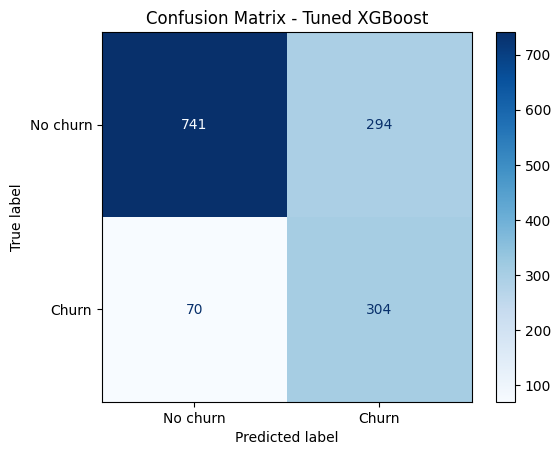

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()


The confusion matrix breaks down the final model's predictions on the test set:

- 304 churners correctly identified (true positives)
- 70 churners missed (false negatives)
- 741 retained customers correctly classified (true negatives)
- 294 false alarms (false positives)

Out of 374 customers who actually churned, the model caught 304, missing only 70. This
reflects the model's design: it prioritises detecting churners, accepting more false
alarms in exchange. For this problem the trade-off is sensible, since missing a churner
(a lost customer) is far more costly than a false alarm (an unnecessary retention offer).

If false positives became a concern, the decision threshold could be raised to reduce
them, at the cost of catching fewer churners.


### ROC Curve

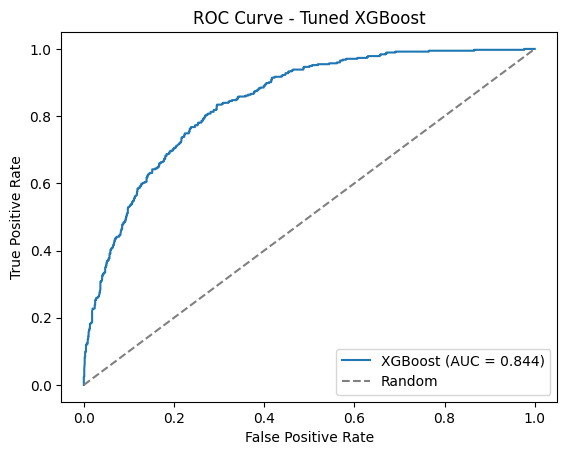

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc_final = roc_auc_score(y_test, y_proba_best)

plt.plot()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc_final:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")  # reference line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost")
plt.legend()
plt.show()

The ROC curve stays well above the diagonal across all thresholds, confirming the model
separates churners from non-churners far better than chance. It rises steeply at the
start, meaning a large share of churners is captured while keeping false positives low.
The area under the curve (AUC = 0.844) summarises this performance in a single value.

## Feature Importante: What Drives Churn

In [16]:
# Usage of features

importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)

# Sort from most to least important
importances = importances.sort_values(ascending=False)


importances

Contract_Two year                        0.285082
Contract_One year                        0.273867
InternetService_Fiber optic              0.105728
InternetService_No                       0.062446
StreamingMovies                          0.040022
tenure                                   0.036994
PaymentMethod_Electronic check           0.032027
OnlineSecurity                           0.025415
PaperlessBilling                         0.023432
StreamingTV                              0.014015
TotalCharges                             0.013713
TechSupport                              0.011438
MultipleLines                            0.010899
PhoneService                             0.010594
Dependents                               0.010571
OnlineBackup                             0.009104
gender_Male                              0.008144
MonthlyCharges                           0.007881
SeniorCitizen                            0.007661
PaymentMethod_Mailed check               0.005527


In [17]:
from sklearn.inspection import permutation_importance

# Shuffle each feature and measure how much ROC-AUC drops on the test set.
# A bigger drop means the feature mattered more. n_repeats averages several
# shuffles for a stable estimate.
perm = permutation_importance(
    best_xgb,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

# Pair the mean importance with feature names and sort, same idea as before
perm_importances = pd.Series(perm.importances_mean, index=X_test.columns)
perm_importances = perm_importances.sort_values(ascending=False)

perm_importances

tenure                                   0.070503
Contract_Two year                        0.055024
InternetService_No                       0.016388
InternetService_Fiber optic              0.015904
Contract_One year                        0.013662
TechSupport                              0.003336
PaymentMethod_Electronic check           0.003198
StreamingMovies                          0.002831
PaperlessBilling                         0.002405
TotalCharges                             0.002324
OnlineSecurity                           0.001685
SeniorCitizen                            0.001202
PhoneService                             0.001068
MultipleLines                            0.000788
MonthlyCharges                           0.000339
Dependents                               0.000144
PaymentMethod_Mailed check               0.000060
DeviceProtection                         0.000000
PaymentMethod_Credit card (automatic)   -0.000004
gender_Male                             -0.000030


### Feature Importance: Permutation Method

Permutation importance was chosen over XGBoost's built-in score, which can overstate
correlated features. It measures the drop in test ROC-AUC when each feature is shuffled,
reflecting real predictive impact on unseen data.


### Drivers of Churn

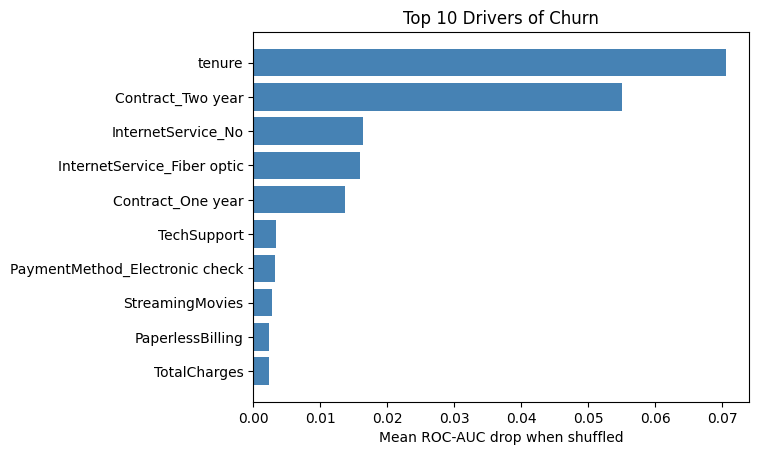

In [18]:
top10 = perm_importances.head(10).sort_values()
plt.barh(top10.index, top10.values, color="steelblue")


plt.xlabel("Mean ROC-AUC drop when shuffled")
plt.title("Top 10 Drivers of Churn")
plt.show()

### Insights

The permutation importance is heavily concentrated in a few features. Tenure shows
the largest impact by a clear margin, followed by the two-year contract. Internet
service type and the one-year contract form a middle group, while the remaining
features sit close to zero and contribute little to the prediction.

Cross-referencing these results with the EDA gives the direction behind each factor.
Tenure is the strongest predictor, and the EDA showed that churn concentrates among
recent customers, so risk is highest early in the relationship and falls as tenure
grows. Contract type points the same way: month-to-month customers churn far more than
those on one or two-year contracts, which explains why long-term contracts rank as
strong protective signals.

Internet service also plays a role, with fiber optic customers showing higher churn,
likely linked to higher prices and expectations. In contrast, variables such as gender,
partner or streaming services carry almost no weight, confirming they are not relevant
for predicting churn.


## Business Recommendations

The analysis points to a small set of factors that drive churn and can be acted upon:

**Encourage longer contracts.** Month-to-month customers churn far more than those on
annual plans. Offering discounts or added benefits for switching to one or two-year
contracts directly targets the strongest controllable driver of churn.

**Focus on the first months.** Churn risk is highest for new customers. Strengthening
onboarding and early engagement during the initial period, when the relationship is
most fragile, can prevent early cancellations.

**Review the fiber optic offering.** Fiber customers show higher churn, which may
reflect price or service expectations. Reviewing pricing and quality for this segment
could reduce attrition among higher-value customers.

**Prioritise retention with the model.** Rather than acting on all customers equally,
the model's churn probability can be used to focus retention efforts and budget on the
highest-risk customers, making the strategy more efficient.


| Finding | Direction | Recommended action |
|---------|-----------|--------------------|
| Contract type is a top driver | Month-to-month churns most | Incentivise one/two-year contracts with discounts or perks |
| Tenure is the strongest predictor | New customers churn most | Strengthen onboarding and engagement in the first months |
| Fiber optic linked to higher churn | Fiber customers leave more | Review pricing and service quality for this segment |
| Model outputs churn probability | High-risk customers identifiable | Target retention budget on the highest-risk customers |



### CSV for PowerBI Dashboards

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Out-of-fold probabilities: each customer is scored by a model that did NOT
# train on them -> honest probabilities, no in-sample optimism.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = cross_val_predict(best_xgb, X, y, cv=cv, method="predict_proba", n_jobs=-1)[
    :, 1
]

raw = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
raw["TotalCharges"] = pd.to_numeric(raw["TotalCharges"], errors="coerce").fillna(0)
raw["churn_probability"] = oof_proba.round(4)

# Percentile-based segments: High = top 20%, Medium = next 30%, Low = bottom 50%.
# More actionable than fixed cutoffs and robust to the probability scaling.
q50, q80 = np.quantile(oof_proba, [0.50, 0.80])
raw["risk_segment"] = pd.cut(
    raw["churn_probability"],
    bins=[-0.01, q50, q80, 1.01],
    labels=["Low", "Medium", "High"],
)

# Helper columns for the Power BI dashboard
raw["churn_flag"] = (raw["Churn"] == "Yes").astype(int)
raw["tenure_bucket"] = pd.cut(
    raw["tenure"],
    bins=[-1, 12, 24, 48, 100],
    labels=["0-12m", "13-24m", "25-48m", "49m+"],
)

raw.to_csv("../data/processed/churn_predictions.csv", index=False)
print("Exported:", raw.shape)

Exported: (7043, 25)
